In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
# gen_profile = pd.read_csv("../memray_generation_stats.csv", index_col=["target_size, density, has_buffer, has_background"])
gen_profile = pd.read_csv("./memray_generation_stats.csv", index_col=[0,1,2,3])
gen_profile = xr.Dataset.from_dataframe(gen_profile)

sim_profile = pd.read_csv("./memray_simulation_stats.csv", index_col=[0,1,2,3])
sim_profile = xr.Dataset.from_dataframe(sim_profile)

sim_opt_profile = pd.read_csv("./memray_simulation_opt_stats.csv", index_col=[0,1,2,3])
sim_opt_profile = xr.Dataset.from_dataframe(sim_opt_profile)

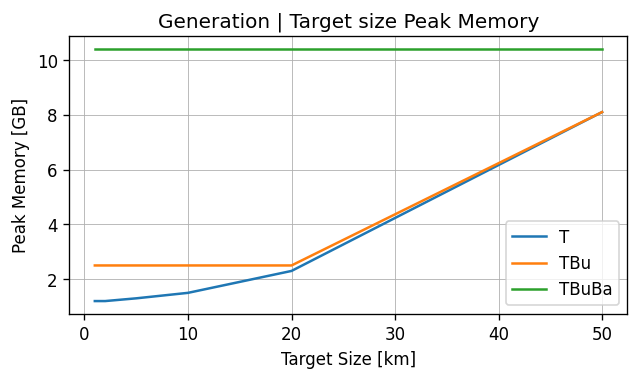

In [3]:
plt.figure(figsize=(6,3),dpi=120)
gen_profile.sel(density=0, has_buffer=False, has_background=False).peak_memory.plot(label="T")
gen_profile.sel(density=0, has_buffer=True, has_background=False).peak_memory.plot(label="TBu")
gen_profile.sel(density=0, has_buffer=True, has_background=True).peak_memory.plot(label="TBuBa")
plt.legend()
plt.grid(which="both", linewidth=0.5)
plt.title("Generation | Target size Peak Memory")
plt.ylabel("Peak Memory [GB]")
plt.xlabel("Target Size [km]")
plt.show()

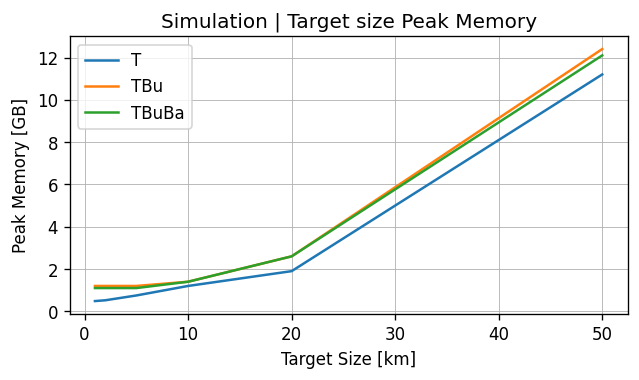

In [4]:
plt.figure(figsize=(6,3),dpi=120)
sim_profile.sel(density=0, has_buffer=False, has_background=False).peak_memory.plot(label="T")
sim_profile.sel(density=0, has_buffer=True, has_background=False).peak_memory.plot(label="TBu")
sim_profile.sel(density=0, has_buffer=True, has_background=True).peak_memory.plot(label="TBuBa")
plt.legend()
plt.grid(which="both", linewidth=0.5)
plt.title("Simulation | Target size Peak Memory")
plt.ylabel("Peak Memory [GB]")
plt.xlabel("Target Size [km]")
plt.show()

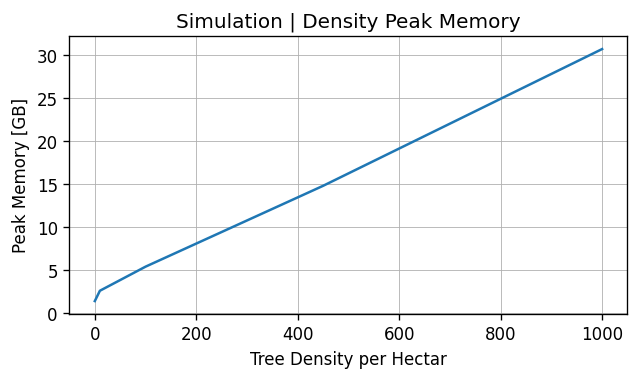

In [5]:
plt.figure(figsize=(6,3),dpi=120)
sim_profile.sel(target_size=10., has_buffer=True, has_background=True).peak_memory.plot(label="T")
# plt.legend()
plt.grid(which="both", linewidth=0.5)
plt.title("Simulation | Density Peak Memory")
plt.ylabel("Peak Memory [GB]")
plt.xlabel("Tree Density per Hectar")
plt.show()

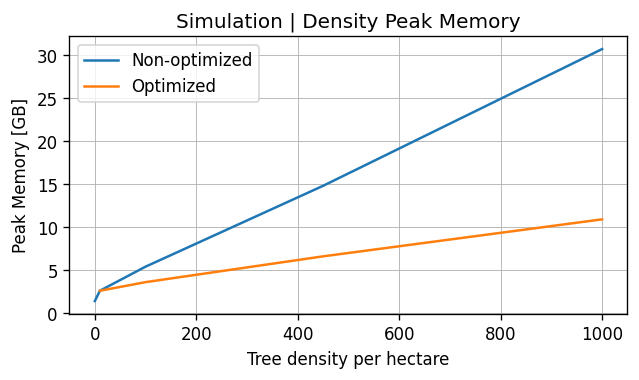

In [8]:
plt.figure(figsize=(6,3),dpi=120)
sim_profile.sel(target_size=10., has_buffer=True, has_background=True).peak_memory.plot(label="Non-optimized")
sim_opt_profile.sel(target_size=10., has_buffer=True, has_background=True).peak_memory.plot(label="Optimized")
plt.legend()
plt.grid(which="both", linewidth=0.5)
plt.title("Simulation | Density Peak Memory")
plt.ylabel("Peak Memory [GB]")
plt.xlabel("Tree density per hectare")
plt.show()